### **Context**

> - Jamboree has helped thousands of students make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
> - They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.


### **Problem Statement:**

> - Help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.


#### **Column Profiling:**

    Serial No. (Unique row ID)
    GRE Scores (out of 340)
    TOEFL Scores (out of 120)
    University Rating (out of 5)
    Statement of Purpose and Letter of Recommendation Strength (out of 5)
    Undergraduate GPA (out of 10)
    Research Experience (either 0 or 1)
    Chance of Admit (ranging from 0 to 1)
    

- Exploratory Data Analysis
- Linear Regression




In [131]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
from matplotlib import figure

import warnings
warnings.filterwarnings('ignore')

In [132]:
import statsmodels.api as sm

In [133]:
import os

directory = r"D:\\Lens\\BusinessCaseSolutions\\Jumbotree"

all_files = []
for dirpath, dirnames, filenames in os.walk(directory):
    for file in filenames:
        all_files.append(os.path.join(dirpath, file))

print("Files:")
for file in all_files:
    print(file)


Files:
D:\\Lens\\BusinessCaseSolutions\\Jumbotree\data.zip
D:\\Lens\\BusinessCaseSolutions\\Jumbotree\JamboreeFinal-JupyterNotebook.pdf
D:\\Lens\\BusinessCaseSolutions\\Jumbotree\Jamboree_Admission.csv
D:\\Lens\\BusinessCaseSolutions\\Jumbotree\Jumbotree_EDA.ipynb
D:\\Lens\\BusinessCaseSolutions\\Jumbotree\__MACOSX\._Jamboree_Admission.csv


In [134]:
from pathlib import Path

directory = Path('')

# List all files (non-recursive)
files = [f for f in directory.iterdir() if f.is_file()]
print(type(file))
# print(files)

# Print each file with aligned columns
for file in files:
    print(f"{file.name:<35} {file.absolute()}")


<class 'str'>
data.zip                            d:\Lens\BusinessCaseSolutions\Jumbotree\data.zip
JamboreeFinal-JupyterNotebook.pdf   d:\Lens\BusinessCaseSolutions\Jumbotree\JamboreeFinal-JupyterNotebook.pdf
Jamboree_Admission.csv              d:\Lens\BusinessCaseSolutions\Jumbotree\Jamboree_Admission.csv
Jumbotree_EDA.ipynb                 d:\Lens\BusinessCaseSolutions\Jumbotree\Jumbotree_EDA.ipynb


In [135]:
data = pd.read_csv("Jamboree_Admission.csv")
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [136]:
data.shape

(500, 9)

In [137]:
df = data.copy()

In [138]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [139]:
df.drop(['Serial No.'], axis=1, inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [140]:
df.nunique()

GRE Score             49
TOEFL Score           29
University Rating      5
SOP                    9
LOR                    9
CGPA                 184
Research               2
Chance of Admit       61
dtype: int64

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [142]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [143]:
print(df.dtypes)

GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object


**University Rating,SOP,LOR,Research are categorical variables.**

**All of the features are numeric , and ordinal . (University Rating,SOP,LOR,Research are discrete ) and rest are continuous**

In [144]:
# isnull ? 

data.isna().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [145]:
# no null values found in data 

In [146]:
df.corr()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL Score,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012,0.792228
University Rating,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance of Admit,0.810351,0.792228,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


**Correlation between two variables** means measuring **how strongly they move together** and in **what direction**.

It tells us:

* **Direction** → whether both variables increase together, one increases while the other decreases, or they are unrelated.
* **Strength** → how closely their movements match.


### **1. Direction**

* **Positive correlation** → When one variable increases, the other also increases.
  Example: **GRE Score** ↑ → **Chance of Admit** ↑.
* **Negative correlation** → When one variable increases, the other decreases.
  Example: **Absences in class** ↑ → **Exam score** ↓.
* **No correlation** → Changes in one don’t systematically affect the other.

### **2. Strength**

Measured using a **correlation coefficient** (most common: **Pearson’s r**), which ranges from **-1 to +1**:

| Value of r       | Meaning                       |
| ---------------- | ----------------------------- |
| **+1**           | Perfect positive relationship |
| **0.7 to 0.9**   | Strong positive               |
| **0.4 to 0.6**   | Moderate positive             |
| **0.1 to 0.3**   | Weak positive                 |
| **0**            | No relationship               |
| **-0.1 to -0.3** | Weak negative                 |
| **-0.4 to -0.6** | Moderate negative             |
| **-0.7 to -0.9** | Strong negative               |
| **-1**           | Perfect negative              |


### **3. Formula (Pearson correlation)**

$$
r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}
$$

Where:

* **Cov(X, Y)** → Covariance between X and Y
* **σX, σY** → Standard deviations of X and Y




### **Example**

We’ll find the **Pearson correlation** between **GRE Score** and **Chance of Admit**.

### **1. The Formula**

$$
r = \frac{\sum (x_i - \bar{x}) (y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}
$$

Where:

* $x_i$ = GRE score of the $i^{th}$ student
* $y_i$ = Chance of Admit of the $i^{th}$ student
* $\bar{x}$ = Mean GRE score
* $\bar{y}$ = Mean Chance of Admit


### **2. The Data**

| GRE (X) | Chance of Admit (Y) |
| ------- | ------------------- |
| 337     | 0.92                |
| 324     | 0.76                |
| 316     | 0.72                |
| 322     | 0.80                |
| 314     | 0.65                |


### **3. Step 1 — Find the Means**

$$
\bar{x} = \frac{337 + 324 + 316 + 322 + 314}{5} = \frac{1613}{5} = 322.6
$$

$$
\bar{y} = \frac{0.92 + 0.76 + 0.72 + 0.80 + 0.65}{5} = \frac{3.85}{5} = 0.77
$$


### **4. Step 2 — Calculate Deviations from Mean**

| X   | X − X̄ | Y    | Y − Ȳ |
| --- | ------ | ---- | ----- |
| 337 | 14.4   | 0.92 | 0.15  |
| 324 | 1.4    | 0.76 | -0.01 |
| 316 | -6.6   | 0.72 | -0.05 |
| 322 | -0.6   | 0.80 | 0.03  |
| 314 | -8.6   | 0.65 | -0.12 |


### **5. Step 3 — Multiply Deviations**

| X − X̄ | Y − Ȳ | Product |
| ------ | ----- | ------- |
| 14.4   | 0.15  | 2.16    |
| 1.4    | -0.01 | -0.014  |
| -6.6   | -0.05 | 0.33    |
| -0.6   | 0.03  | -0.018  |
| -8.6   | -0.12 | 1.032   |

Sum of products:

$$
\sum (X - \bar{X})(Y - \bar{Y}) = 2.16 - 0.014 + 0.33 - 0.018 + 1.032 = 3.49
$$


### **6. Step 4 — Squares of Deviations**

| X − X̄ | (X − X̄)² | Y − Ȳ | (Y − Ȳ)² |
| ------ | --------- | ----- | -------- |
| 14.4   | 207.36    | 0.15  | 0.0225   |
| 1.4    | 1.96      | -0.01 | 0.0001   |
| -6.6   | 43.56     | -0.05 | 0.0025   |
| -0.6   | 0.36      | 0.03  | 0.0009   |
| -8.6   | 73.96     | -0.12 | 0.0144   |

Sum of squares:

$$
\sum (X - \bar{X})^2 = 207.36 + 1.96 + 43.56 + 0.36 + 73.96 = 327.2
$$

$$
\sum (Y - \bar{Y})^2 = 0.0225 + 0.0001 + 0.0025 + 0.0009 + 0.0144 = 0.0404
$$


### **7. Step 5 — Plug Into Formula**

$$
r = \frac{3.49}{\sqrt{(327.2) \cdot (0.0404)}}
$$

First, multiply:

$$
327.2 \times 0.0404 = 13.22088
$$

Square root:

$$
\sqrt{13.22088} \approx 3.636
$$

Finally:

$$
r = \frac{3.49}{3.636} \approx 0.96
$$


### **8. Interpretation**

* **r ≈ 0.96** → **Very strong positive correlation**.
* This means that in this dataset, higher GRE scores are strongly associated with a higher chance of admission.
* Since it’s close to **+1**, the relationship is almost perfectly linear for this sample.



<Axes: >

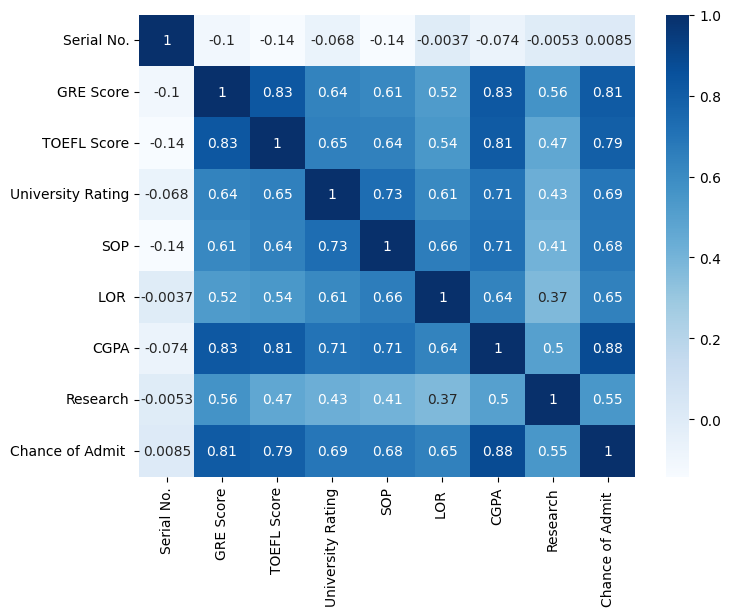

In [147]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="Blues")

In [148]:
df.columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit ']

####  **pairplot , correlation and trend line with each variables:**

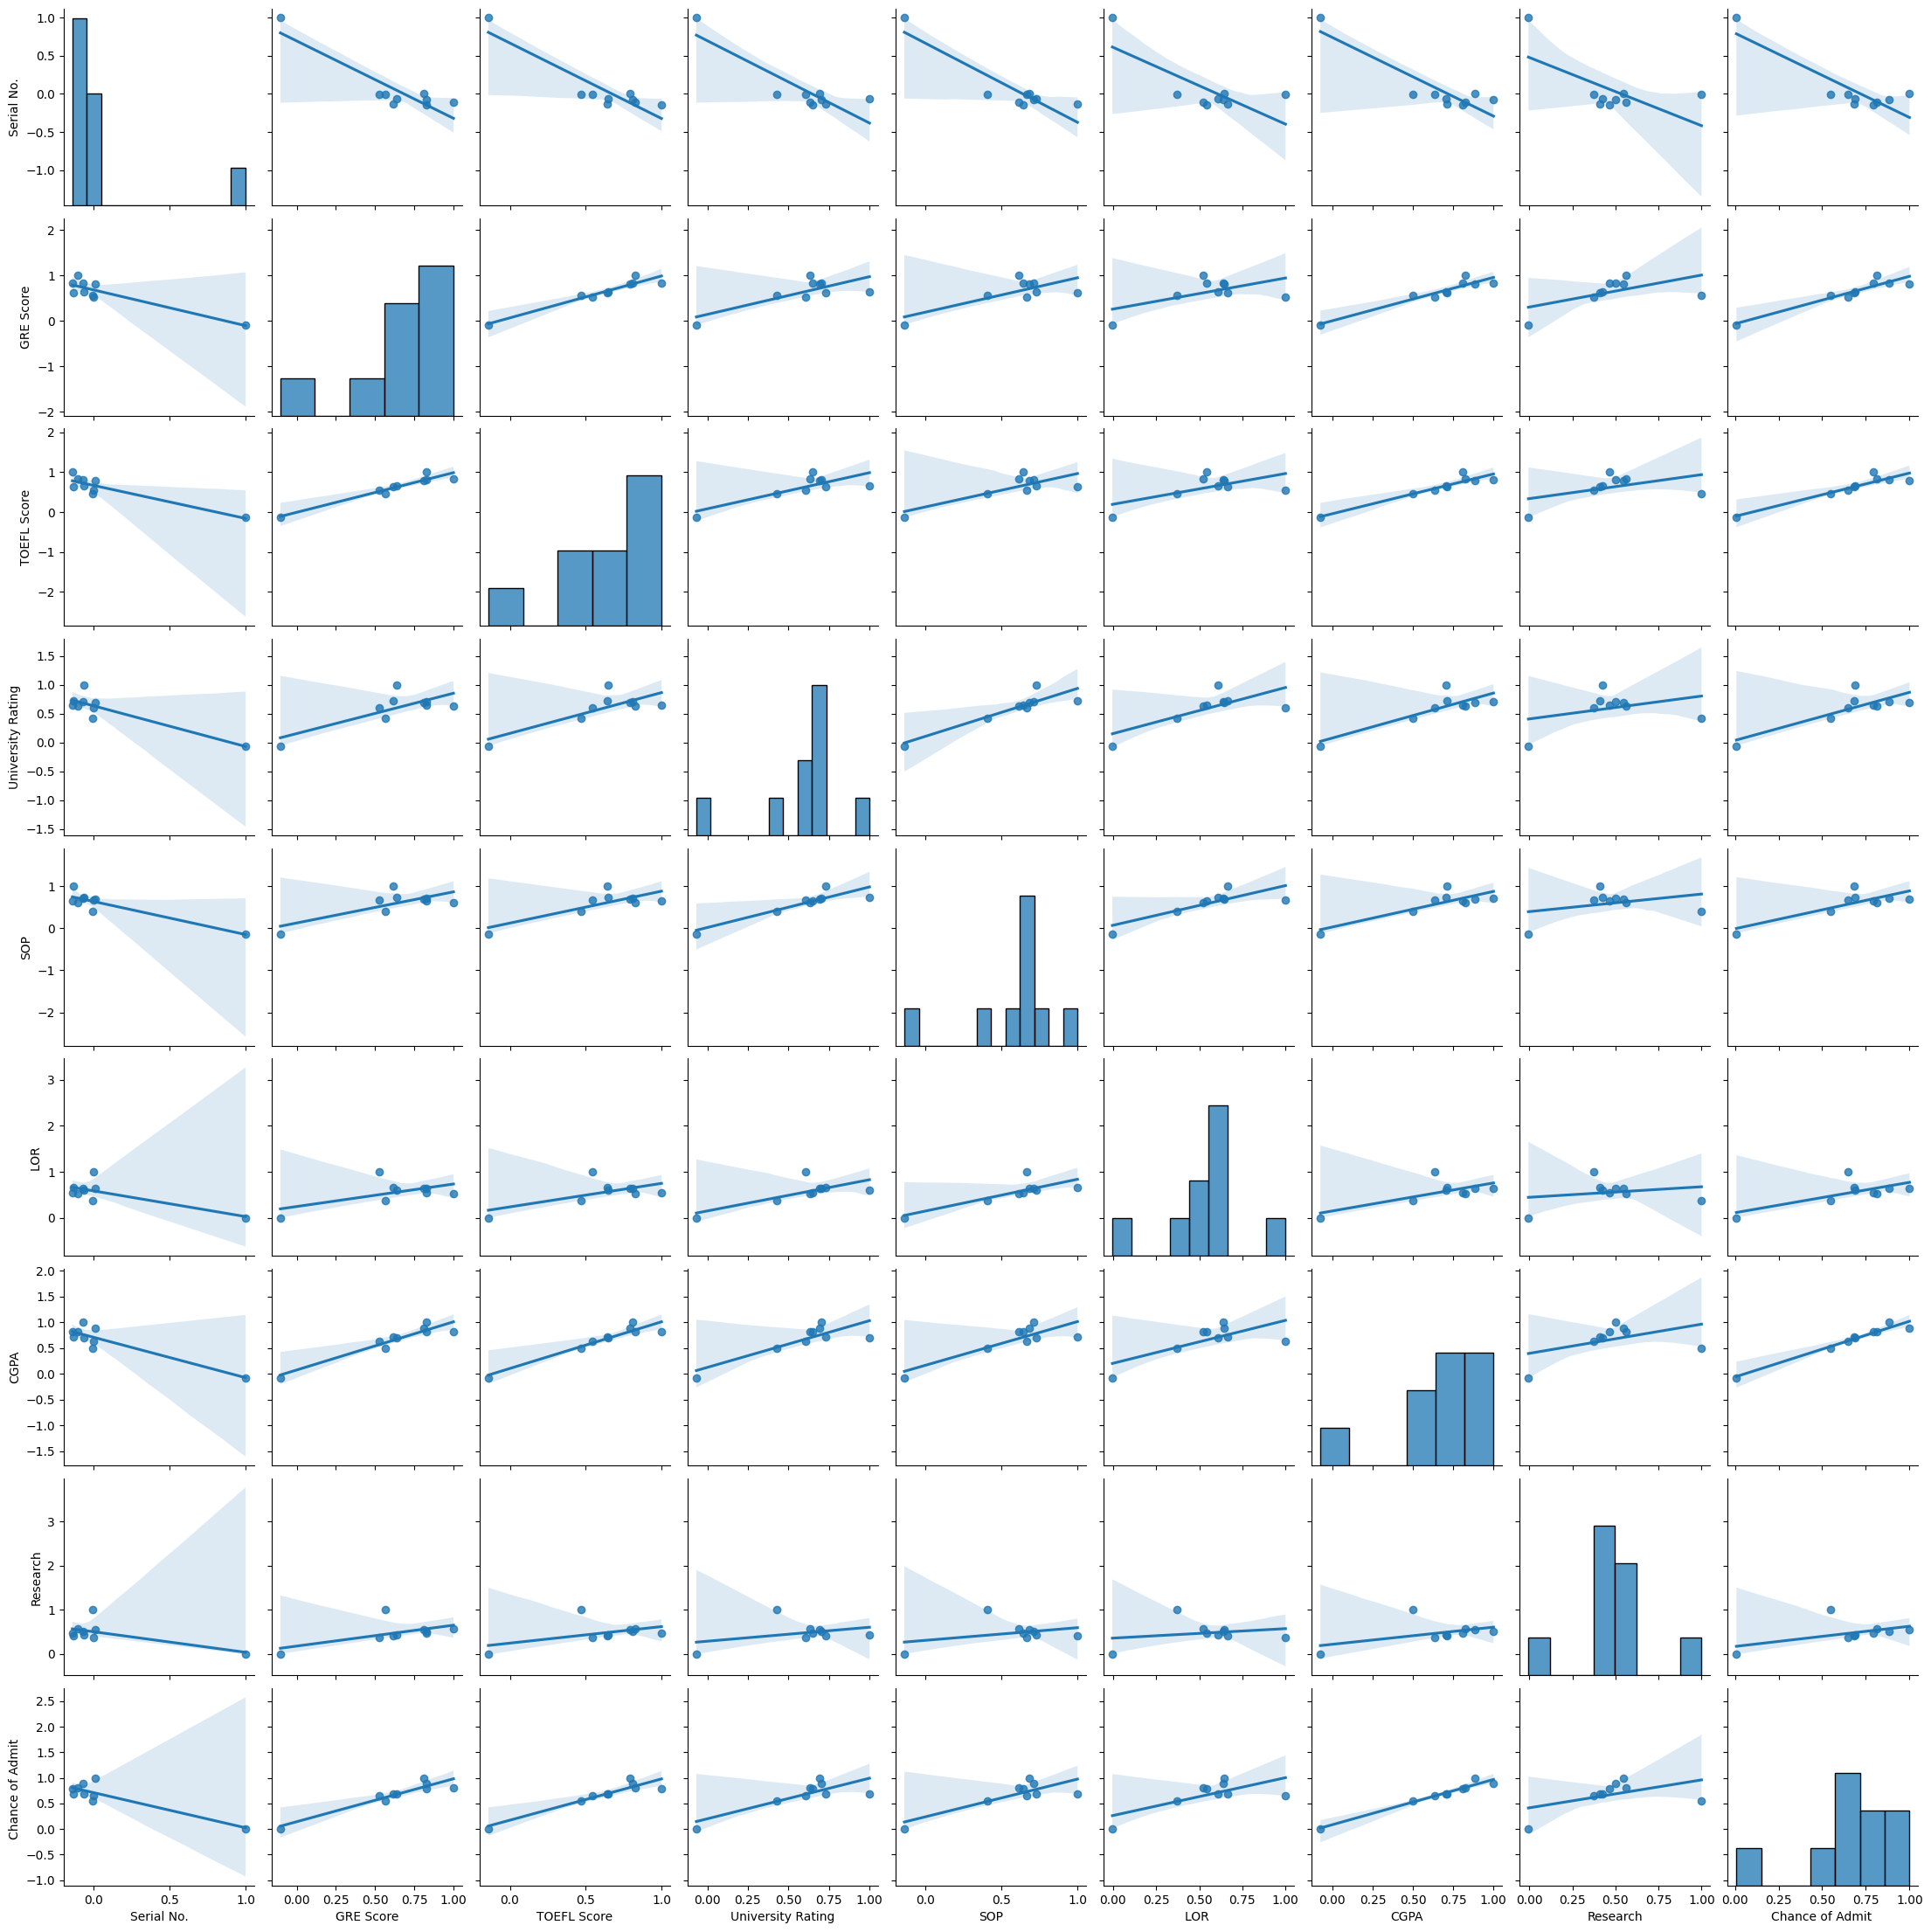

In [149]:
sns.pairplot(data.corr(), kind='reg')

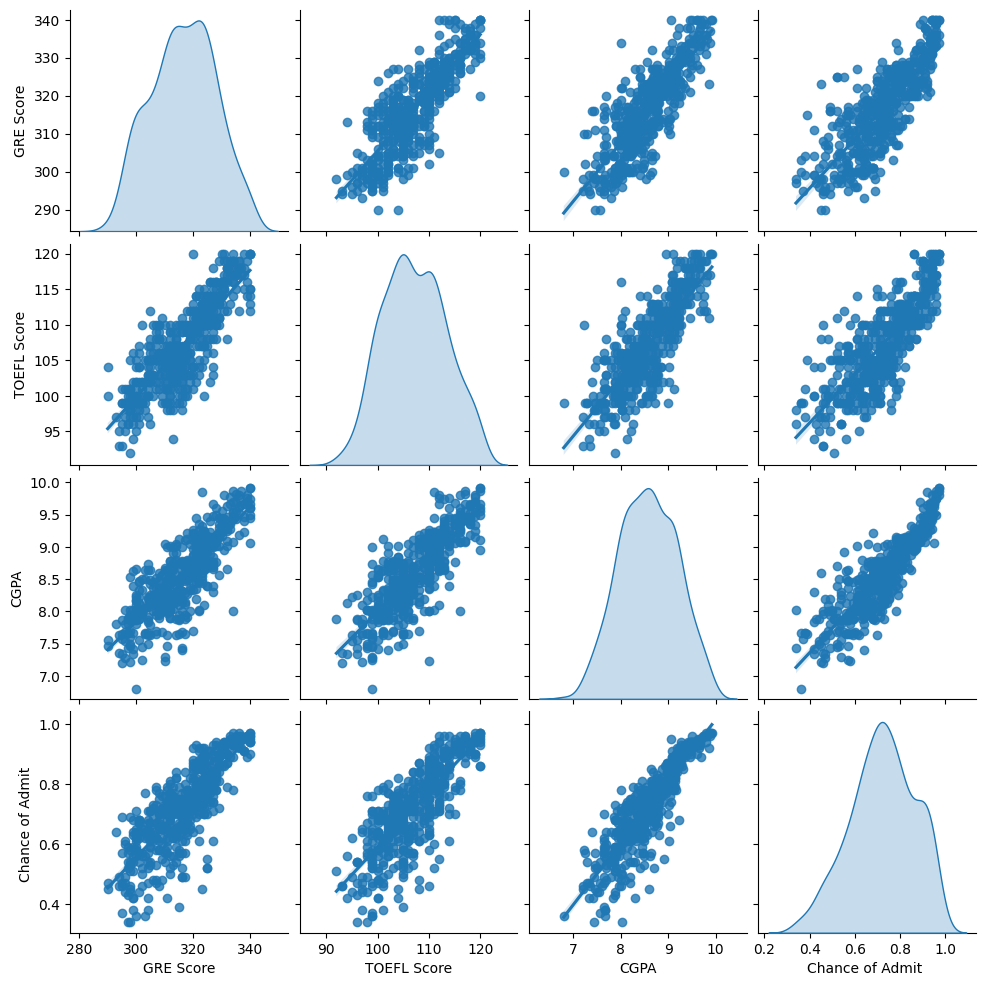

In [150]:
sns.pairplot(df[['GRE Score', 'TOEFL Score', 'CGPA', 'Chance of Admit ']], kind='reg', diag_kind='kde')
plt.show()


### **Check for the outliers Using IQR method**

In [151]:
def detect_outliers(data):
    length_before=len(data)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR=Q3-Q1
    upperbound=Q3+1.5*IQR 
    lowerbound=Q1-1.5*IQR 
    if lowerbound<0:
        lowerbound=0

    length_after=len(data[(data>lowerbound)&(data<upperbound)])
    return f"{np.round(length_before-length_after)/length_before, 4}"

In [152]:
def detect_outliers(data):
    # Input: data = [1, 2, 3, 4, 100]
    
    # Step 1: Calculate the length of the input data
    # length_before = len(data) = 5
    length_before = len(data)
    
    # Step 2: Calculate the first quartile (Q1), the 25th percentile
    # For [1, 2, 3, 4, 100], Q1 = 2 (median of lower half [1, 2])
    Q1 = np.percentile(data, 25)
    
    # Step 3: Calculate the third quartile (Q3), the 75th percentile
    # For [1, 2, 3, 4, 100], Q3 = 4 (median of upper half [3, 4, 100])
    Q3 = np.percentile(data, 75)
    
    # Step 4: Calculate the Interquartile Range (IQR)
    # IQR = Q3 - Q1 = 4 - 2 = 2
    IQR = Q3 - Q1
    
    # Step 5: Calculate the upper bound for outliers
    # upperbound = Q3 + 1.5 * IQR = 4 + 1.5 * 2 = 4 + 3 = 7
    upperbound = Q3 + 1.5 * IQR
    
    # Step 6: Calculate the lower bound for outliers
    # lowerbound = Q1 - 1.5 * IQR = 2 - 1.5 * 2 = 2 - 3 = -1
    lowerbound = Q1 - 1.5 * IQR
    
    # Step 7: If lowerbound is negative, set it to 0
    # Since lowerbound = -1 < 0, set lowerbound = 0
    if lowerbound < 0:
        lowerbound = 0
    
    # Step 8: Calculate the length of data after removing outliers
    # Data points where 0 < data < 7: [1, 2, 3, 4] (100 is an outlier as it's > 7)
    # length_after = len([1, 2, 3, 4]) = 4
    length_after = len(data[(data > lowerbound) & (data < upperbound)])
    
    # Step 9: Calculate the proportion of outliers
    # Proportion = (length_before - length_after) / length_before = (5 - 4) / 5 = 1 / 5 = 0.2
    # Round to 4 decimal places: 0.2000
    return f"{np.round((length_before - length_after) / length_before, 4)}"

# Final output for data = [1, 2, 3, 4, 100]: "0.2000"

In [153]:
for col in data.columns:
    print(col," : ",detect_outliers(data[col]))

Serial No.  :  0.0
GRE Score  :  0.0
TOEFL Score  :  0.0
University Rating  :  0.0
SOP  :  0.0
LOR   :  0.024
CGPA  :  0.0
Research  :  0.44
Chance of Admit   :  0.004


In [154]:
# there are no significant amount of outliers found in the data 


#### **Checking the distributions for Continuous Variables :** 


In [155]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

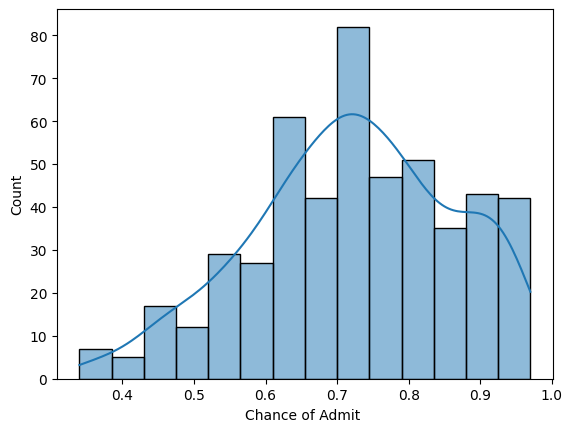

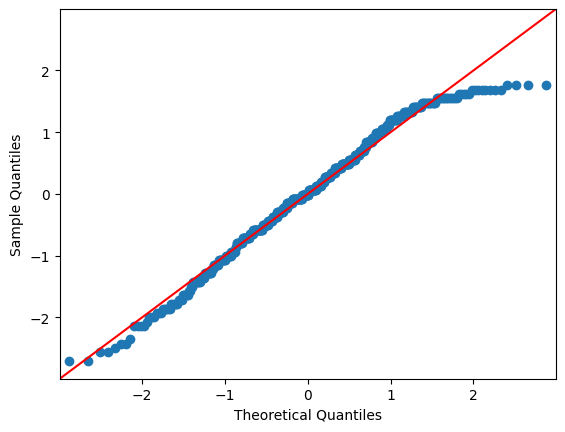

In [156]:
sns.histplot(data=df, x="Chance of Admit ", kde=True)

# Generate Q-Q plot
sm.qqplot(df['Chance of Admit '], fit=True, line="45")
plt.show()


### **Use of `sns.histplot` (Histogram with KDE)**

* Shows the **distribution** of a variable.
* Histogram: tells how often values occur in different ranges (frequency).
* KDE (Kernel Density Estimate): smooth curve to visualize probability density.

### **Use of `qqplot` (Quantile-Quantile Plot)**

* Compares your data’s distribution to a **theoretical distribution** (often normal).
* Helps check **normality** — points close to the diagonal mean the data is roughly normal.
* Large deviations from the line indicate non-normality or skew.


**Chance of admit and GRE score are nearly normally distrubted.**

In [157]:
df.columns = ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
'Research', 'Chance_of_Admit']

In [158]:
df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admit'],
      dtype='object')

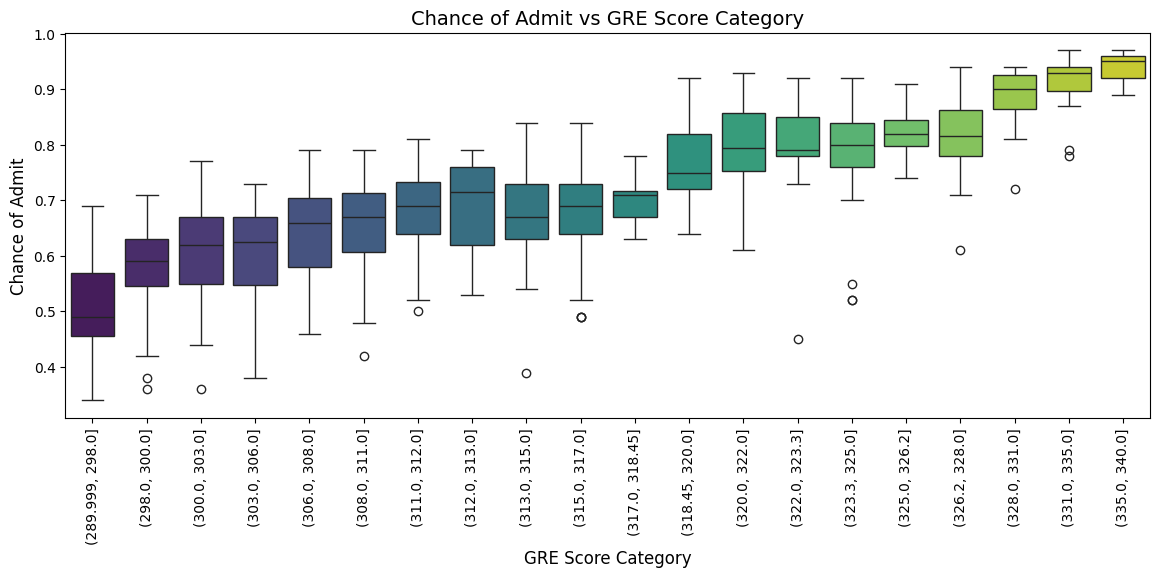

In [159]:
# Create GRE score categories (20 equal-sized bins)
df["GRE_SCORE_CATEGORY"] = pd.qcut(df["GRE_Score"], 20)

# Plot boxplot with customized colors
plt.figure(figsize=(14, 5))
sns.boxplot(
    y=df["Chance_of_Admit"],
    x=df["GRE_SCORE_CATEGORY"],
    palette="viridis"  # Color palette for better visibility
)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Add titles and labels
plt.title("Chance of Admit vs GRE Score Category", fontsize=14)
plt.xlabel("GRE Score Category", fontsize=12)
plt.ylabel("Chance of Admit", fontsize=12)

plt.show()


In [160]:
#### From above boxplot (distribution of chance of admition (probability of getting admition) as per GRE score  ) : with higher GRE score , there is high probability of getting an admition . 

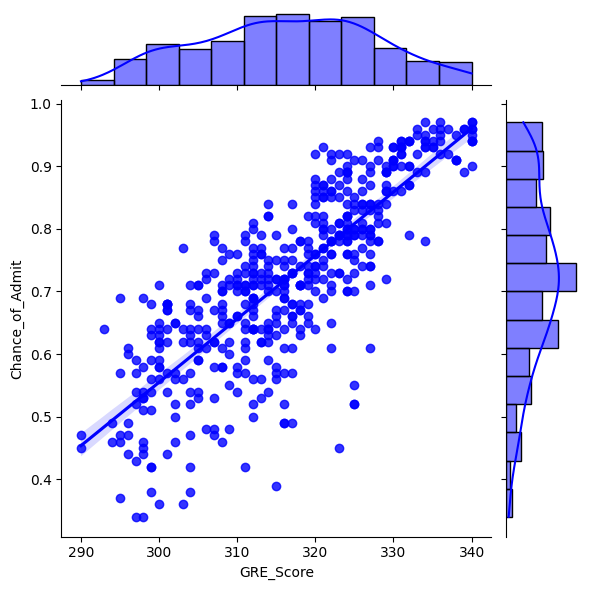

In [161]:
sns.jointplot(
    x=df['GRE_Score'],
    y=df["Chance_of_Admit"],
    kind="reg",        # Regression line
    color="blue"       # Optional color
)
plt.show()


**from above regression line| jointplot and boxlot we can observe a strong correlation of GRE score and chance of admit .**

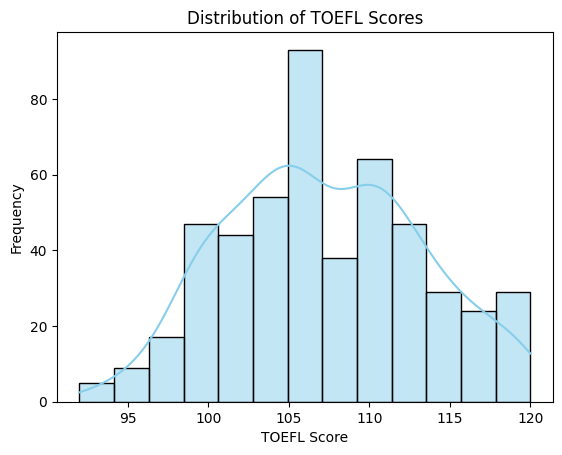

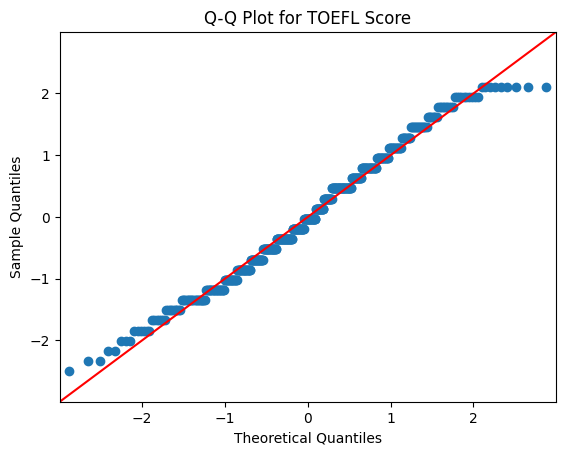

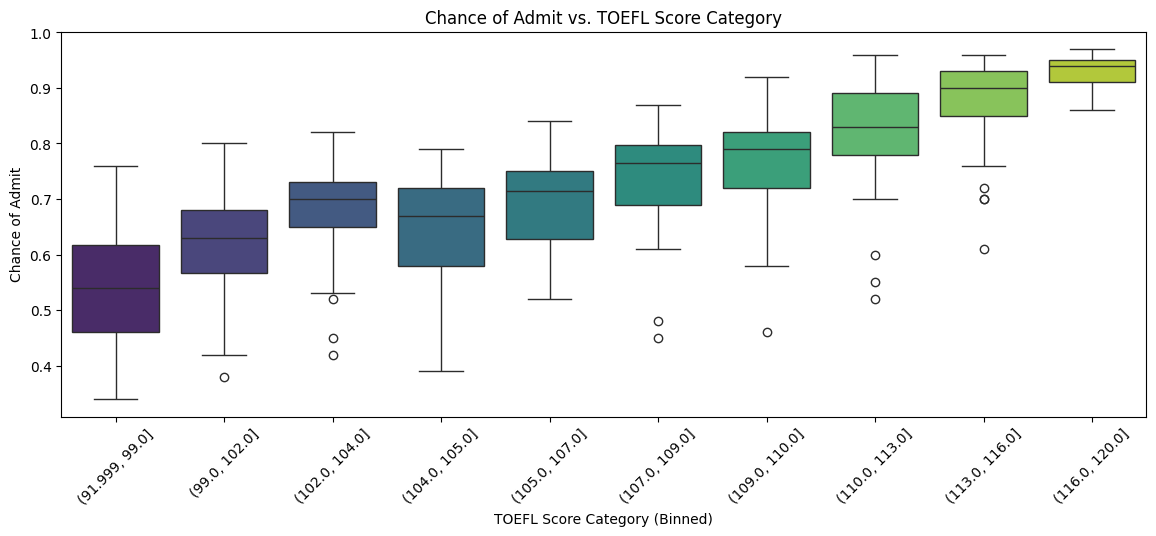

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# 1. Distribution plot
sns.histplot(df["TOEFL_Score"], kde=True, color="skyblue")
plt.title("Distribution of TOEFL Scores")
plt.xlabel("TOEFL Score")
plt.ylabel("Frequency")
plt.show()

# 2. Q-Q plot
sm.qqplot(df["TOEFL_Score"], fit=True, line="45")
plt.title("Q-Q Plot for TOEFL Score")
plt.show()

# 3. Boxplot with binned TOEFL Scores
df["TOEFL_Category"] = pd.qcut(df["TOEFL_Score"], 10)
plt.figure(figsize=(14, 5))
sns.boxplot(
    x="TOEFL_Category", 
    y="Chance_of_Admit", 
    data=df, 
    palette="viridis"
)
plt.xticks(rotation=45)
plt.xlabel("TOEFL Score Category (Binned)")
plt.ylabel("Chance of Admit")
plt.title("Chance of Admit vs. TOEFL Score Category")
plt.show()


**Students having high toefl score , has higher probability of getting admition.** 

In [163]:
df[["GRE_Score","TOEFL_Score","Chance_of_Admit"]].corr()

,GRE_Score,TOEFL_Score,Chance_of_Admit
GRE_Score,1.000000,0.827200,0.810351
TOEFL_Score,0.827200,1.000000,0.792228
Chance_of_Admit,0.810351,0.792228,1.000000


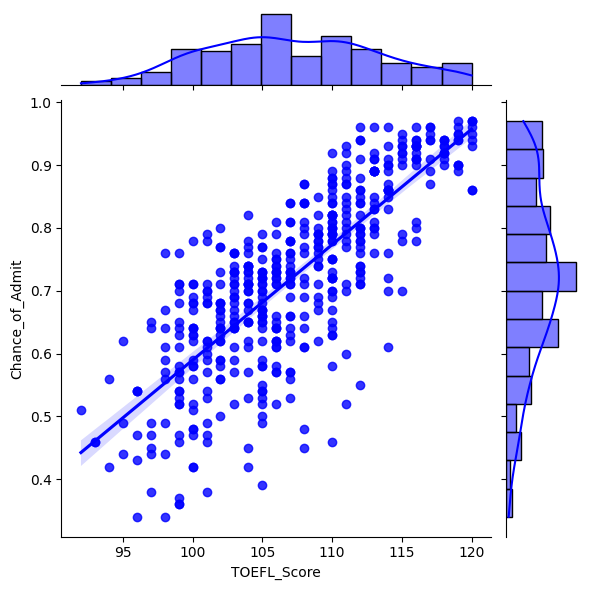

In [164]:
sns.jointplot(
    x=df["TOEFL_Score"],
    y=df["Chance_of_Admit"],
    kind="reg",
    color="blue"
)

*GRE scores and TOEFT Score have very high correlation with Chance of Admit*

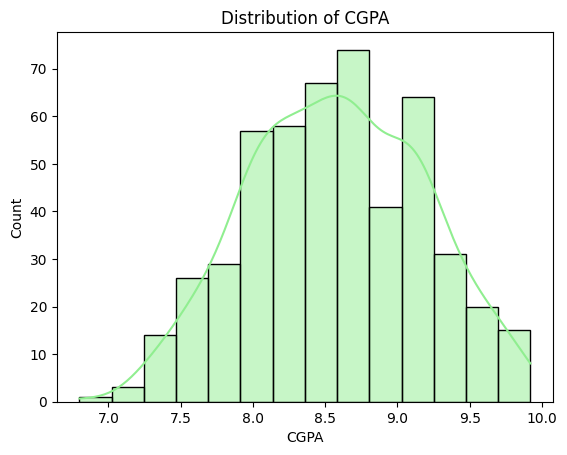

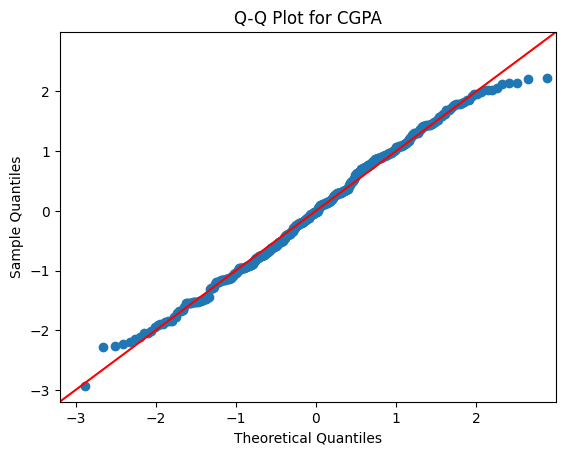

In [165]:

# 1. Distribution plot
# sns.histplot(data=df["CGPA"], kde=True, color="lightgreen")
sns.histplot(data=df, x="CGPA", kde=True, color="lightgreen")
plt.title("Distribution of CGPA")
plt.show()

# 2. Q-Q plot
sm.qqplot(df["CGPA"], fit=True, line="45")
plt.title("Q-Q Plot for CGPA")
plt.show()


In [166]:
df[["CGPA","Chance_of_Admit"]].corr()

,CGPA,Chance_of_Admit
CGPA,1.000000,0.882413
Chance_of_Admit,0.882413,1.000000


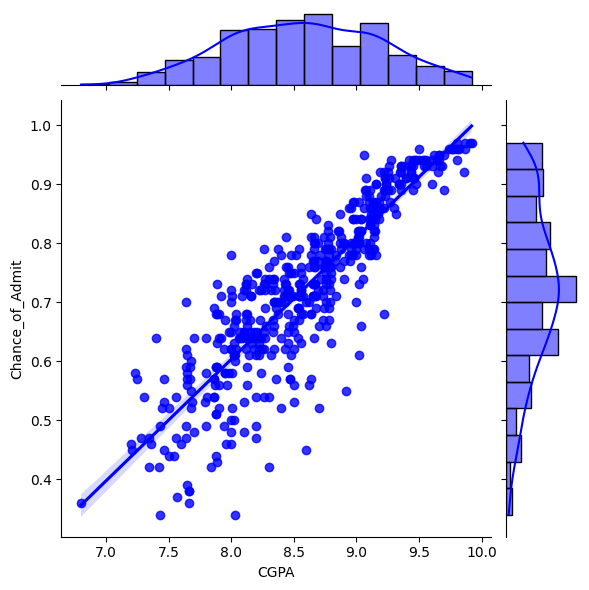

In [167]:
sns.jointplot(
    x=df["CGPA"],
    y=df["Chance_of_Admit"],
    kind="reg",
    color="blue"
)

**CGPA also has a very high correlation with Chance of Admition**

**GRE score, TOEFL score and CGPA has a strong correlation with chance of addmission.**

<div class="alert alert-success">Checking for Rest of the Features and Their Distribution</div>


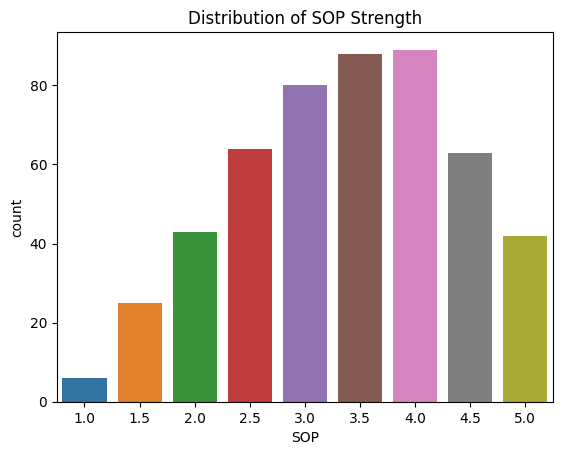

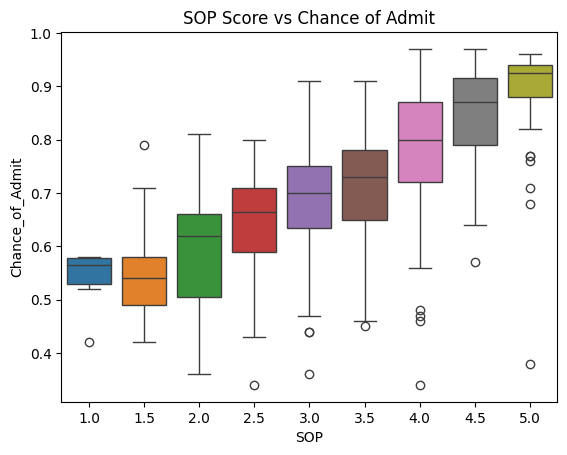

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'df' is your DataFrame
sns.countplot(x="SOP", data=df, palette="tab10")
plt.title("Distribution of SOP Strength")
plt.show()

sns.boxplot(x="SOP", y="Chance_of_Admit", data=df, palette="tab10")
plt.title("SOP Score vs Chance of Admit")
plt.show()


<div class="alert alert-success">
Distribution above shows, most occurring SOP strength is between 2.5 to 4.5, and having higher strength of SOP brings more chance of getting admission!
</div>


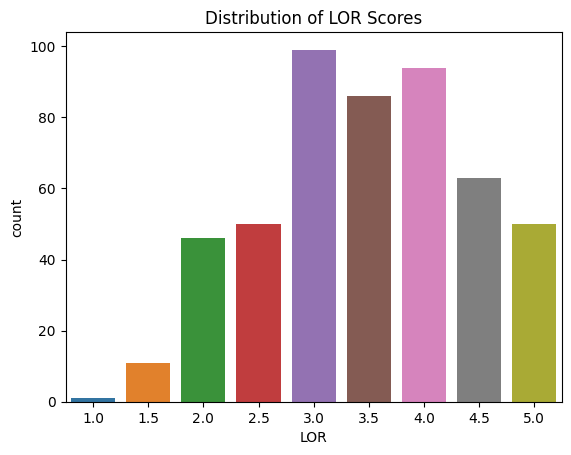

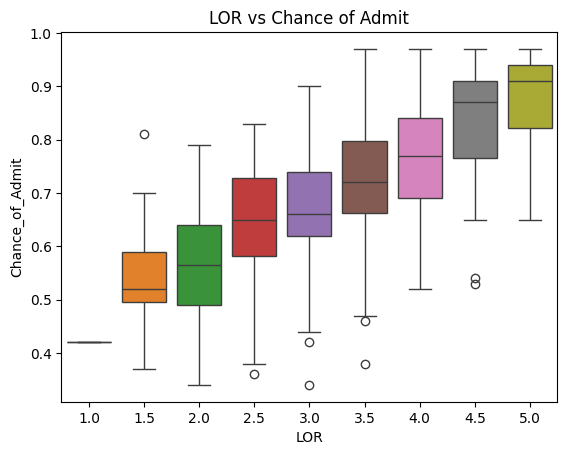

In [169]:
# Countplot for LOR distribution
sns.countplot(x="LOR", data=df, palette="tab10")
plt.title("Distribution of LOR Scores")
plt.show()

# Boxplot for LOR vs Chance of Admit
sns.boxplot(x="LOR", y="Chance_of_Admit", data=df, palette="tab10")
plt.title("LOR vs Chance of Admit")
plt.show()





<div class="alert alert-success">
Statement of Purpose and Letter of Recommendation Strength increases then the chances of admition aslo increases

In [170]:
df[["SOP","LOR","Chance_of_Admit"]].corr()

,SOP,LOR,Chance_of_Admit
SOP,1.000000,0.663707,0.684137
LOR,0.663707,1.000000,0.645365
Chance_of_Admit,0.684137,0.645365,1.000000


<h3 class="alert alert-success">
Distribution of Cateogircal variables 

In [172]:
df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admit', 'GRE_SCORE_CATEGORY', 'TOEFL_Category'],
      dtype='object')

In [175]:
df["University_Rating"].value_counts()

University_Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64

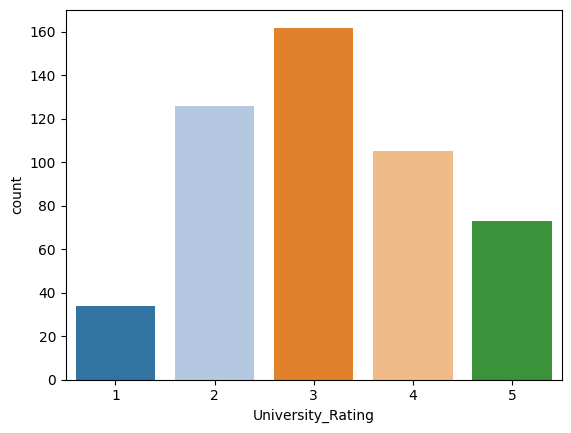

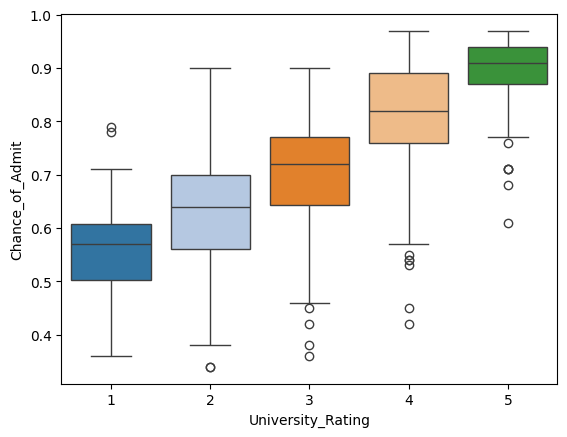

In [189]:
# Count plot
sns.countplot(x=df["University_Rating"], palette="tab20")
plt.show()

# Box plot
sns.boxplot(
    x=df["University_Rating"],
    y=df["Chance_of_Admit"],
    palette="tab20"
)
plt.show()


<span class="alert alert-danger">
Higher the university rating , increase the chance of getting admission . 

In [186]:
sns.palettes.SEABORN_PALETTES.keys()

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])

In [185]:
# Seaborn named palettes
seaborn_palettes = list(sns.palettes.SEABORN_PALETTES.keys())

# Matplotlib colormaps
matplotlib_palettes = plt.colormaps()

print("Seaborn palettes:")
print(seaborn_palettes)

print("\nMatplotlib colormaps:")
print(list(matplotlib_palettes))


Seaborn palettes:
['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6']

Matplotlib colormaps:
['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of some built-in palettes you can try
palettes = [
    "deep", "muted", "bright", "pastel", "dark", "colorblind",
    "husl", "coolwarm", "vlag", "rocket", "mako", "flare",
    "crest", "tab10", "tab20", "tab20b", "tab20c"
]

# Plot each palette
# for palette in palettes:
#     sns.palplot(sns.color_palette(palette))
#     plt.title(palette)
#     plt.show()


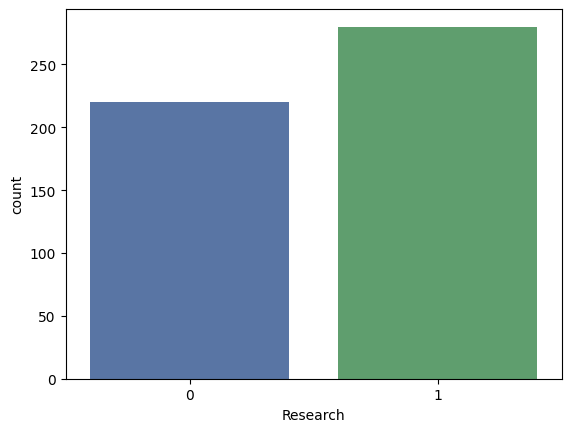

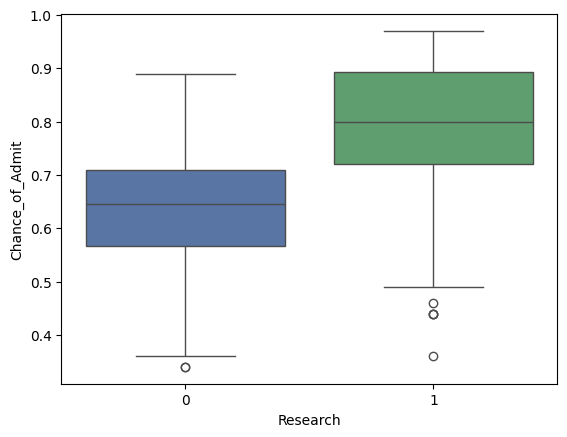

In [196]:
sns.countplot(
    x="Research",   # column name as string
    data=df,        # dataframe
    palette="deep6"
)
plt.show()

sns.boxplot(
    x="Research",   # column name as string
    y="Chance_of_Admit",
    data=df,        # dataframe
    palette="deep6"
)

plt.show()


<p class="alert alert-danger">
For research student has higher chance of getting the admission. 

<h4 class="alert alert-success">
Assumption check for Linear Regression 

In [197]:
df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admit', 'GRE_SCORE_CATEGORY', 'TOEFL_Category'],
      dtype='object')

Plotting GRE_Score...
Plotting TOEFL_Score...
Plotting University_Rating...
Plotting SOP...
Plotting LOR...
Plotting CGPA...
Plotting Research...
Plotting Chance_of_Admit...


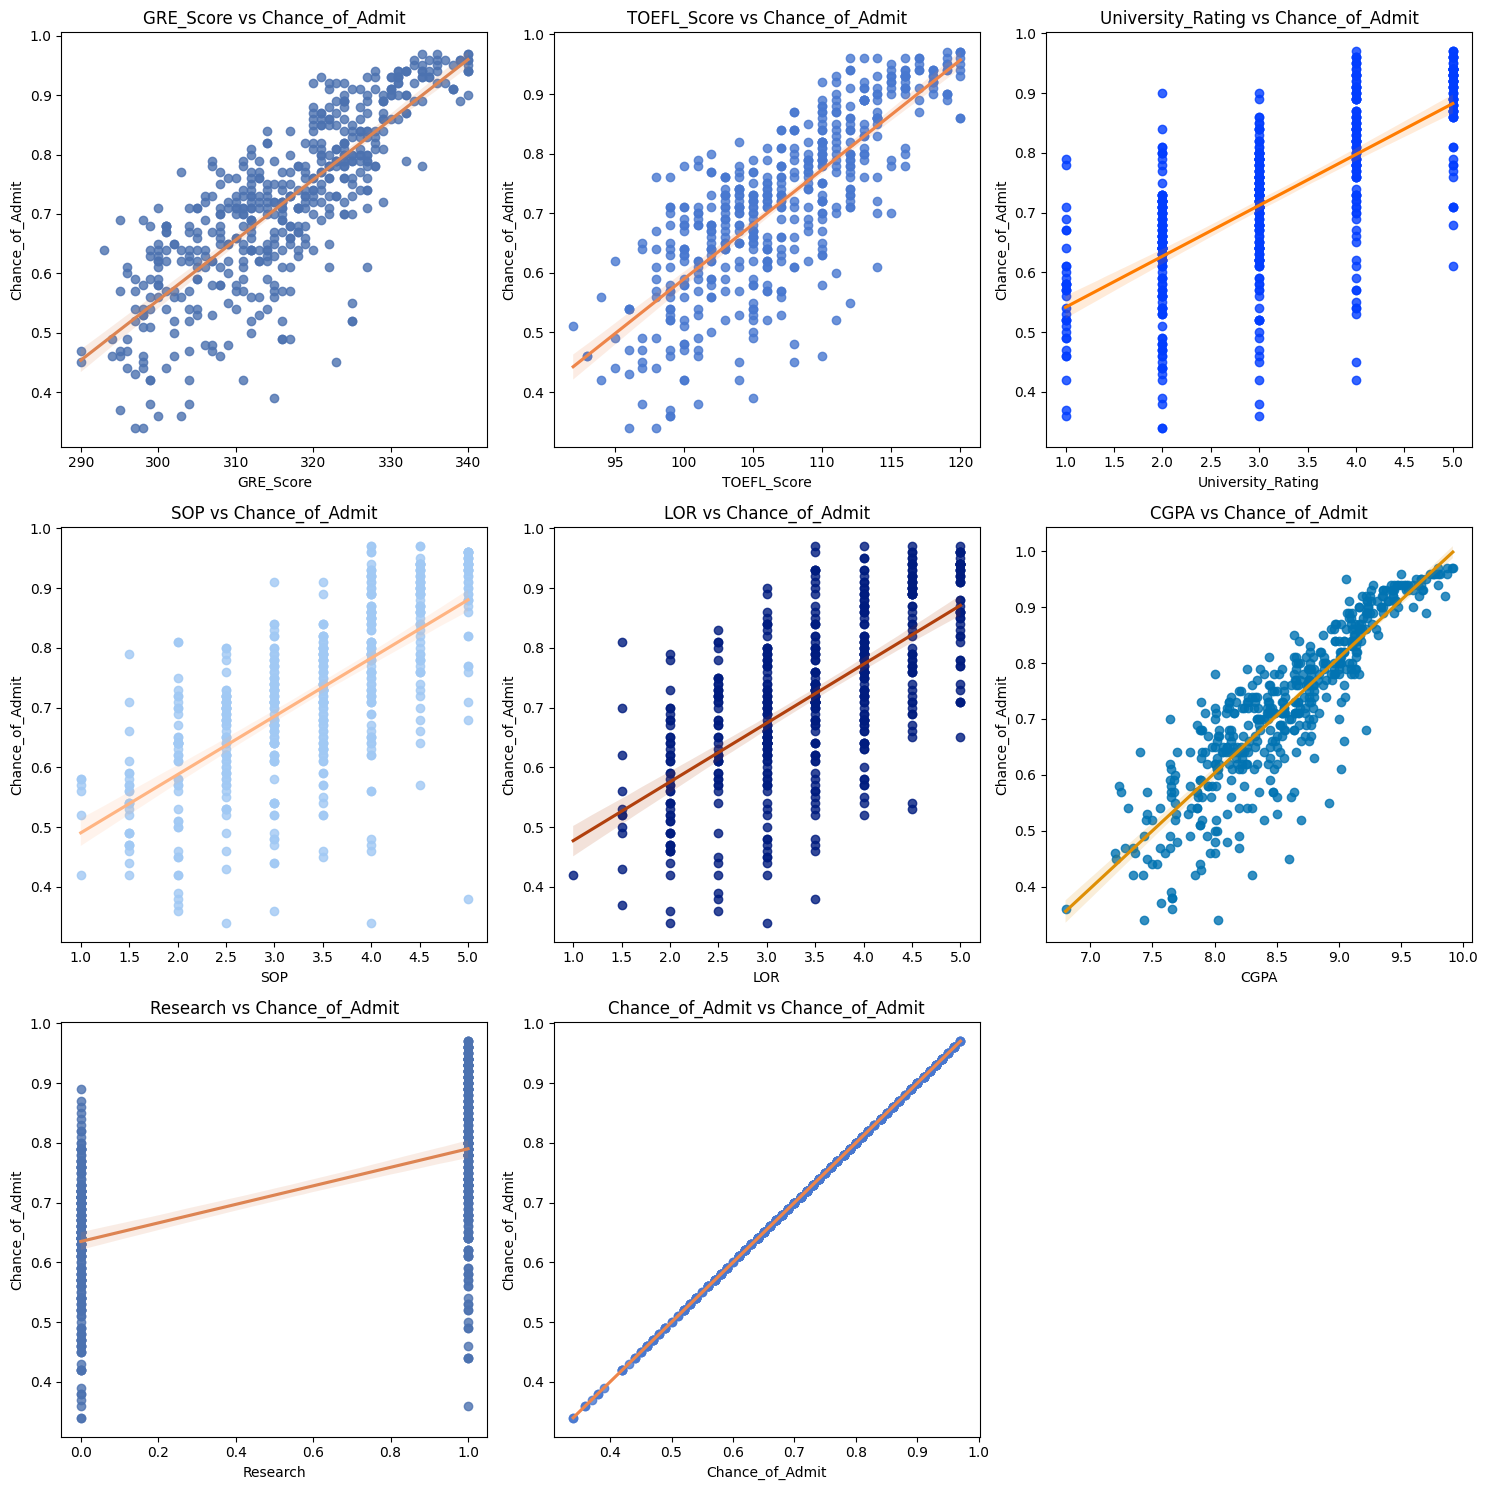

In [202]:
palettes = ["deep", "muted", "bright", "pastel", "dark", "colorblind"]

# Get numeric columns except the last one
numeric_cols = [col for col in df.columns[:-1] if pd.api.types.is_numeric_dtype(df[col])]

num_plots = len(numeric_cols)
plots_per_row = 3
num_rows = (num_plots + plots_per_row - 1) // plots_per_row  # ceiling division

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(plots_per_row*5, num_rows*5))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, col in enumerate(numeric_cols):
    print(f"Plotting {col}...")
    sns.regplot(
        x=df[col],
        y=df["Chance_of_Admit"],
        ax=axes[i],
        scatter_kws={"color": sns.color_palette(palettes[i % len(palettes)])[0]},  # first color from palette
        line_kws={"color": sns.color_palette(palettes[i % len(palettes)])[1]},     # second color from palette
    )
    axes[i].set_title(f"{col} vs Chance_of_Admit")
    
# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<div class="alert alert-success">
LOR, SOP , University rating and research are categorical variable, and amonst them chances of admits varies a lot.
       

<h4 class="alert alert-success">
Regression using sklearn
</h4>

<div class="alert alert-danger">
Closed form solution technique for Linear Regression | OLS

In [203]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [244]:
data = pd.read_csv("Jamboree_Admission.csv")
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [248]:
data.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [254]:
X = data.drop(['Serial No.', 'Chance of Admit '], axis=1)
y = data['Chance of Admit ']

In [255]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [256]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [259]:
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [260]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [261]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [262]:
for idx, col in enumerate(x_train.columns):
    print(f"Coefficient for {col} is {model.coef_[idx]}")

Coefficient for GRE Score is 0.0024344383948367563
Coefficient for TOEFL Score is 0.0029958733715185794
Coefficient for University Rating is 0.002568797743526611
Coefficient for SOP is 0.001813690012812437
Coefficient for LOR  is 0.017237983661425454
Coefficient for CGPA is 0.11252708444059877
Coefficient for Research is 0.02402678764620614


In [263]:
model.intercept_

np.float64(-1.421447071901647)

In [266]:
y_pred = model.predict(x_test)
y_pred[:5]

array([0.91457473, 0.79518127, 0.57265986, 0.70736968, 0.81588282])

In [268]:

comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison_df.head(10))


     Actual  Predicted
361    0.93   0.914575
73     0.84   0.795181
374    0.39   0.572660
155    0.77   0.707370
104    0.74   0.815883
394    0.89   0.862066
377    0.47   0.474597
124    0.57   0.648509
68     0.68   0.823787
450    0.82   0.807415


In [269]:
r2_score(y_test, y_pred)

0.8188432567829629

In [270]:
mean_absolute_error(y_test, y_pred)

0.04272265427705369

In [271]:
mean_squared_error(y_test, y_pred)

0.0037046553987884097

In [272]:
print("MSE:",mean_squared_error(y_test,y_pred)) # MSE
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred))) #RMSE
print("MAE :",mean_absolute_error(y_test,y_pred) ) # MAE
print("r2_score:",r2_score(y_test,y_pred)) # r2score

MSE: 0.0037046553987884097
RMSE: 0.06086588041578311
MAE : 0.04272265427705369
r2_score: 0.8188432567829629


<div class="alert alert-success">
Since all the data is numeric and ordinal, keeping all the features , r_2 score is observed as 0.81 on test data. 

<h4 class="alert alert-success">
Using Sklearn | Stochastic Gradient Descent

In [ ]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [287]:
# Using Sklearn | Stochastic Gradient Descent Algorithm

# Load and split the data
X = data.drop(['Serial No.', 'Chance of Admit '], axis=1)
y = data['Chance of Admit ']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Preprocess the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)  # apply same transformation to test data

# Train the model
from sklearn.linear_model import SGDRegressor
sgd = make_pipeline(StandardScaler(), SGDRegressor(max_iter=1000, tol=1e-3))

sgd.fit(X_train, y_train)

# Make predictions
y_pred = sgd.predict(X_test)

# Evaluate the model
y_test = y_test.values
r2_score(y_test, y_pred)

# Note: overserving very similar result as OLS,
# trying different algorithms and different variations with features.

0.7899110362662334

In [288]:
# Evaluate the model
print("R² score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² score: 0.7899110362662334
Mean Absolute Error: 0.04723035153176805
Mean Squared Error: 0.004490012929359509


In [289]:
# Linear Regression using Statsmodel library
import statsmodels.api as sm 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


X_train_sm = X_train
X_test_sm = X_test
X_train_sm = sm.add_constant(X_train_sm)
X_test_sm = sm.add_constant(X_test_sm)

model = sm.OLS(y_train, X_train_sm).fit()

In [290]:
data.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [291]:

# Check for multicollinearity and further re-training model and testing
data.drop(['Serial No.', 'Chance of Admit '], axis=1).corr()


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
GRE Score,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398
TOEFL Score,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012
University Rating,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526
CGPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311
Research,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000


<Axes: >

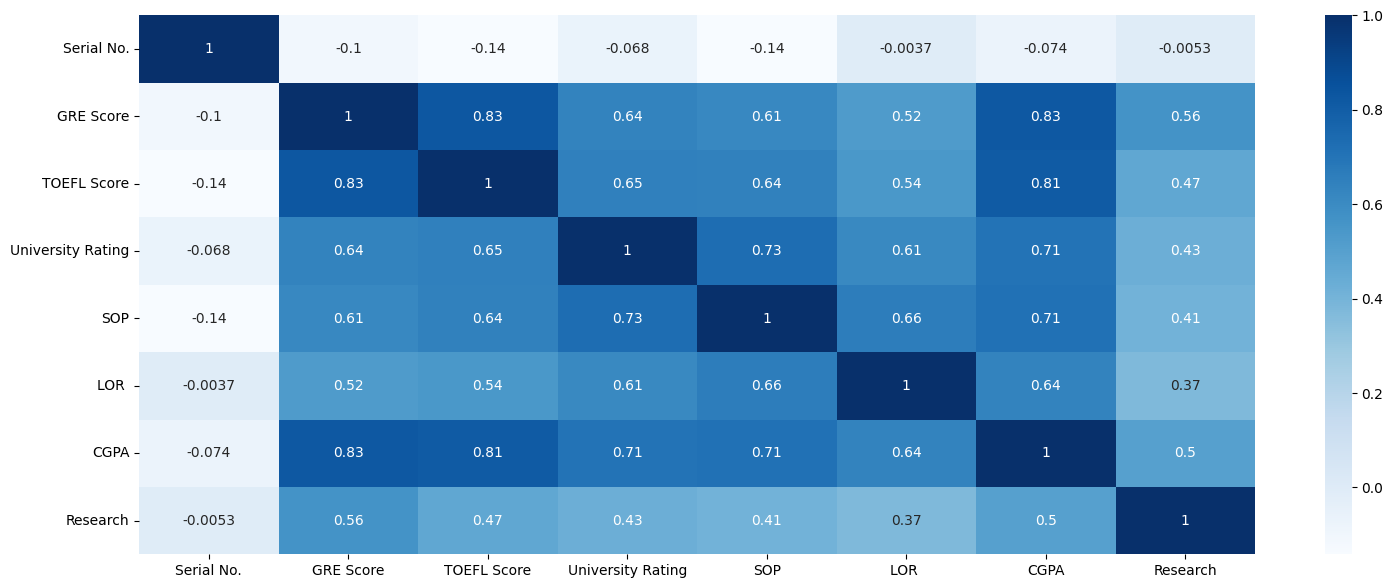

In [296]:
# Plot heatmap
plt.figure(figsize=(18,7))
sns.heatmap(data.drop(['Chance of Admit '], axis=1).corr(), annot=True, cmap="Blues")

<div class="alert alert-success">
GRE Score and Toefl score have a very high correlation with CGPA
# GRE score and TOEFL score also have a very high correlation
# CGPA and University Rating , SOP strength and CGPA, have a high correlation .


In [297]:
# checking for Multicolinearity using vif score:

# Variance Inflation Factor:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [301]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vifs = []
for i in range(X_train_sm.shape[1]):
    vifs.append(variance_inflation_factor(exog=X_train_sm.values, exog_idx=i))

pd.DataFrame({'coef_name': X_train_sm.columns, 'vif': np.around(vifs, 2)})


,coef_name,vif
0,const,1571.81
1,GRE Score,4.24
2,TOEFL Score,4.06
3,University Rating,2.59
4,SOP,2.71
5,LOR,1.98
6,CGPA,4.77
7,Research,1.47


In [303]:
# residuals = actual - predicted
residuals = y_train - model.predict(X_train_sm)
print("Mean of residuals:", residuals.mean())


Mean of residuals: -1.5031031974643838e-15


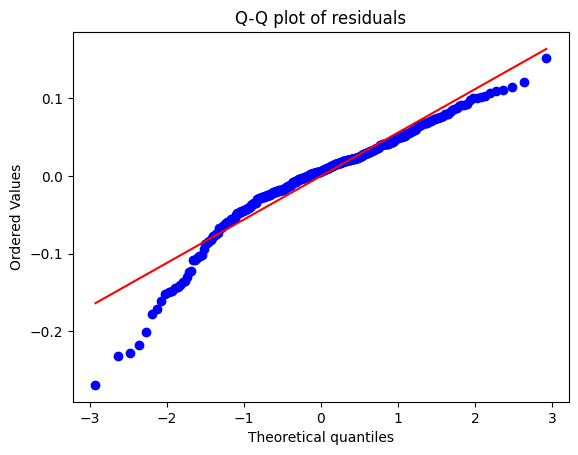

In [306]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")
plt.show()


In [307]:
y_predicted = model.predict(X_test_sm)

In [309]:
y_predicted

129    0.929429
280    0.725446
440    0.541938
384    0.968982
225    0.553784
         ...   
387    0.620452
117    0.499755
468    0.824264
395    0.810745
146    0.666845
Length: 100, dtype: float64

In [298]:
# VIF score are all below 5 , Look good , there doesnt seem significant multicolinearity.

# model building
olsres = sm.OLS(y_train,X_train_sm).fit()

print(olsres.summary())

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     272.1
Date:                Tue, 12 Aug 2025   Prob (F-statistic):          3.33e-146
Time:                        18:18:35   Log-Likelihood:                 573.41
No. Observations:                 400   AIC:                            -1131.
Df Residuals:                     392   BIC:                            -1099.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.3418      0.11

In [311]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [312]:
# Add constant for statsmodels
X_train_sm = sm.add_constant(X_train)

vifs = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif_df = pd.DataFrame({'Feature': X_train_sm.columns, 'VIF': np.round(vifs, 2)})
print(vif_df)


             Feature      VIF
0              const  1683.78
1          GRE Score     4.49
2        TOEFL Score     3.66
3  University Rating     2.57
4                SOP     2.79
5               LOR      1.98
6               CGPA     4.65
7           Research     1.52


In [313]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
y_train_pred = model_lr.predict(X_train)
y_test_pred = model_lr.predict(X_test)


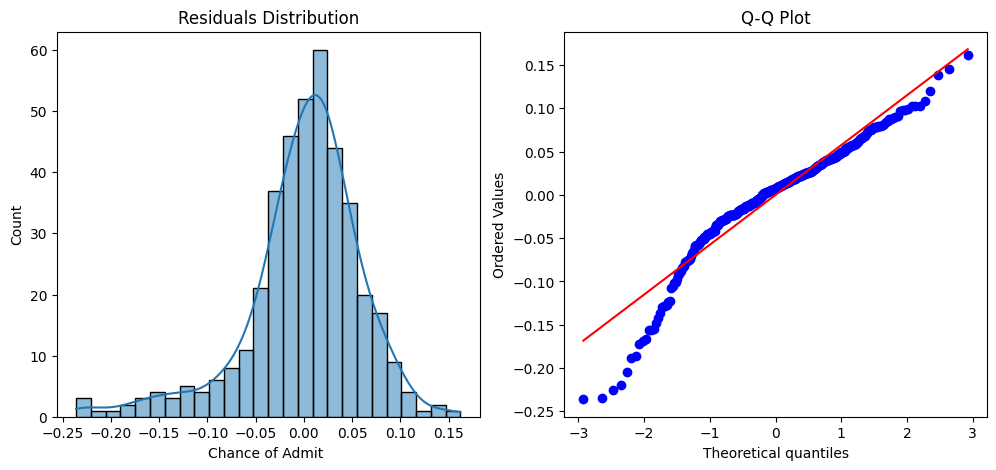

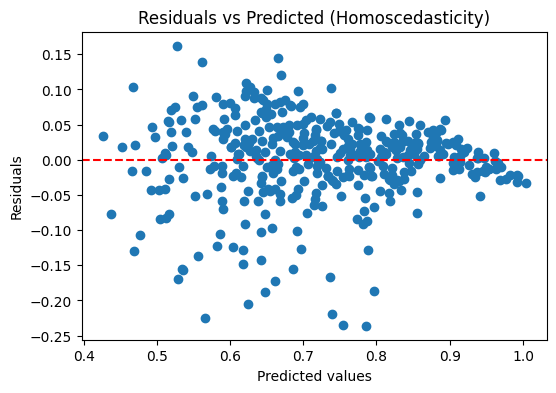

Mean of residuals: 1.4113710200547302e-16


In [314]:
residuals = y_train - y_train_pred

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')

plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.show()

# Residuals vs predicted
plt.figure(figsize=(6,4))
plt.scatter(y_train_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Homoscedasticity)')
plt.show()

print("Mean of residuals:", residuals.mean())


In [315]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


In [316]:
def evaluate_model(y_true, y_pred, n, p):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, n, p)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Adjusted R2': adj_r2}


In [317]:
metrics_train = evaluate_model(y_train, y_train_pred, len(y_train), X_train.shape[1])
metrics_test = evaluate_model(y_test, y_test_pred, len(y_test), X_test.shape[1])

print("Linear Regression Train Metrics:", metrics_train)
print("Linear Regression Test Metrics:", metrics_test)


Linear Regression Train Metrics: {'MSE': 0.0035265554784557574, 'RMSE': np.float64(0.059384808482100516), 'MAE': 0.04253334061164315, 'R2': 0.8210671369321554, 'Adjusted R2': 0.8178719072345153}
Linear Regression Test Metrics: {'MSE': 0.0037046553987884097, 'RMSE': np.float64(0.06086588041578311), 'MAE': 0.04272265427705369, 'R2': 0.8188432567829629, 'Adjusted R2': 0.8050595915381884}


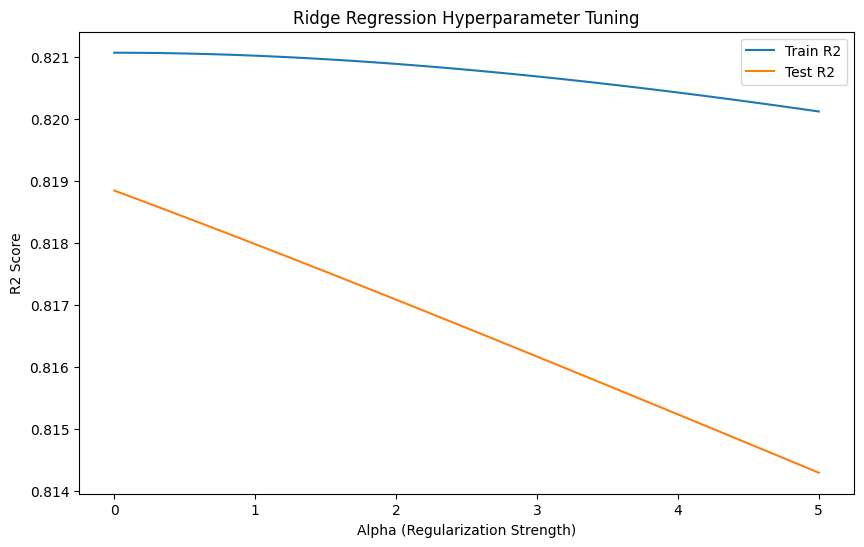

In [318]:
alphas = np.arange(0, 5.01, 0.1)
train_scores = []
test_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    train_scores.append(ridge.score(X_train, y_train))
    test_scores.append(ridge.score(X_test, y_test))

plt.figure(figsize=(10,6))
plt.plot(alphas, train_scores, label='Train R2')
plt.plot(alphas, test_scores, label='Test R2')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score')
plt.title('Ridge Regression Hyperparameter Tuning')
plt.legend()
plt.show()


In [319]:
best_alpha = alphas[np.argmax(test_scores)]
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train, y_train)

y_train_pred_ridge = ridge_best.predict(X_train)
y_test_pred_ridge = ridge_best.predict(X_test)

ridge_train_metrics = evaluate_model(y_train, y_train_pred_ridge, len(y_train), X_train.shape[1])
ridge_test_metrics = evaluate_model(y_test, y_test_pred_ridge, len(y_test), X_test.shape[1])

print(f"Best alpha for Ridge: {best_alpha}")
print("Ridge Train Metrics:", ridge_train_metrics)
print("Ridge Test Metrics:", ridge_test_metrics)


Best alpha for Ridge: 0.0
Ridge Train Metrics: {'MSE': 0.0035265554784557574, 'RMSE': np.float64(0.059384808482100516), 'MAE': 0.04253334061164317, 'R2': 0.8210671369321554, 'Adjusted R2': 0.8178719072345153}
Ridge Test Metrics: {'MSE': 0.003704655398788416, 'RMSE': np.float64(0.06086588041578316), 'MAE': 0.04272265427705374, 'R2': 0.8188432567829625, 'Adjusted R2': 0.805059591538188}


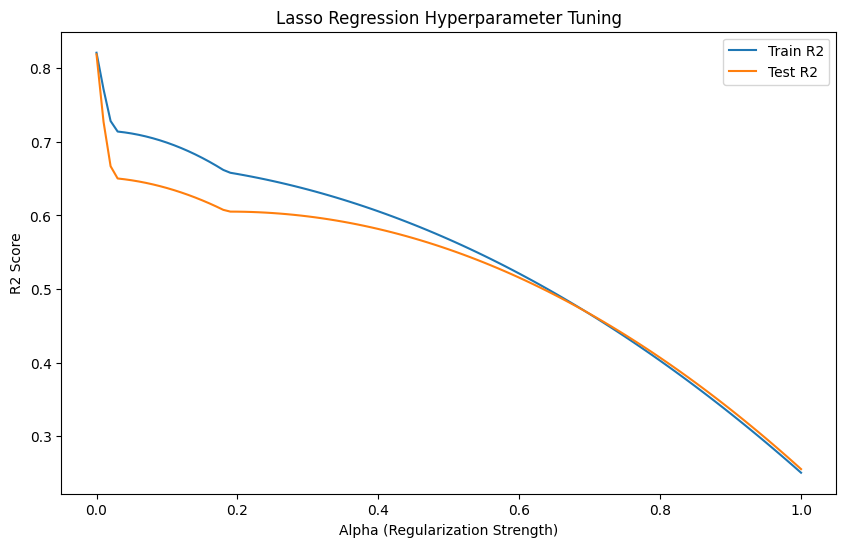

Best alpha for Lasso: 0.0
Lasso Train Metrics: {'MSE': 0.003526555478455756, 'RMSE': np.float64(0.0593848084821005), 'MAE': 0.04253334061164308, 'R2': 0.8210671369321555, 'Adjusted R2': 0.8178719072345154}
Lasso Test Metrics: {'MSE': 0.0037046553987884027, 'RMSE': np.float64(0.06086588041578305), 'MAE': 0.04272265427705366, 'R2': 0.8188432567829632, 'Adjusted R2': 0.8050595915381886}


In [320]:
alphas_lasso = np.arange(0, 1.01, 0.01)
train_scores_lasso = []
test_scores_lasso = []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    train_scores_lasso.append(lasso.score(X_train, y_train))
    test_scores_lasso.append(lasso.score(X_test, y_test))

plt.figure(figsize=(10,6))
plt.plot(alphas_lasso, train_scores_lasso, label='Train R2')
plt.plot(alphas_lasso, test_scores_lasso, label='Test R2')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score')
plt.title('Lasso Regression Hyperparameter Tuning')
plt.legend()
plt.show()

best_alpha_lasso = alphas_lasso[np.argmax(test_scores_lasso)]
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train, y_train)

y_train_pred_lasso = lasso_best.predict(X_train)
y_test_pred_lasso = lasso_best.predict(X_test)

lasso_train_metrics = evaluate_model(y_train, y_train_pred_lasso, len(y_train), X_train.shape[1])
lasso_test_metrics = evaluate_model(y_test, y_test_pred_lasso, len(y_test), X_test.shape[1])

print(f"Best alpha for Lasso: {best_alpha_lasso}")
print("Lasso Train Metrics:", lasso_train_metrics)
print("Lasso Test Metrics:", lasso_test_metrics)


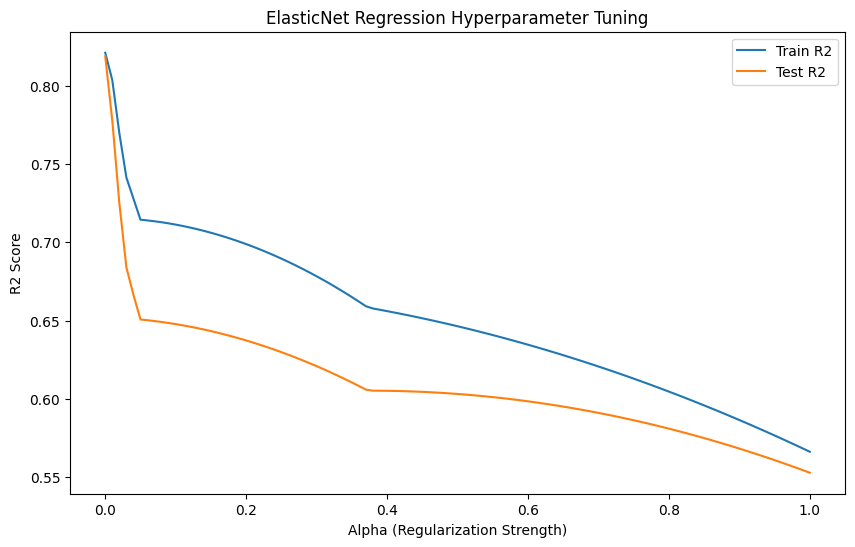

Best alpha for ElasticNet: 0.0
ElasticNet Train Metrics: {'MSE': 0.003526555478455756, 'RMSE': np.float64(0.0593848084821005), 'MAE': 0.04253334061164308, 'R2': 0.8210671369321555, 'Adjusted R2': 0.8178719072345154}
ElasticNet Test Metrics: {'MSE': 0.0037046553987884027, 'RMSE': np.float64(0.06086588041578305), 'MAE': 0.04272265427705366, 'R2': 0.8188432567829632, 'Adjusted R2': 0.8050595915381886}


In [321]:
alphas_en = np.arange(0, 1.01, 0.01)
train_scores_en = []
test_scores_en = []

for alpha in alphas_en:
    en = ElasticNet(alpha=alpha, max_iter=10000)
    en.fit(X_train, y_train)
    train_scores_en.append(en.score(X_train, y_train))
    test_scores_en.append(en.score(X_test, y_test))

plt.figure(figsize=(10,6))
plt.plot(alphas_en, train_scores_en, label='Train R2')
plt.plot(alphas_en, test_scores_en, label='Test R2')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score')
plt.title('ElasticNet Regression Hyperparameter Tuning')
plt.legend()
plt.show()

best_alpha_en = alphas_en[np.argmax(test_scores_en)]
en_best = ElasticNet(alpha=best_alpha_en, max_iter=10000)
en_best.fit(X_train, y_train)

y_train_pred_en = en_best.predict(X_train)
y_test_pred_en = en_best.predict(X_test)

en_train_metrics = evaluate_model(y_train, y_train_pred_en, len(y_train), X_train.shape[1])
en_test_metrics = evaluate_model(y_test, y_test_pred_en, len(y_test), X_test.shape[1])

print(f"Best alpha for ElasticNet: {best_alpha_en}")
print("ElasticNet Train Metrics:", en_train_metrics)
print("ElasticNet Test Metrics:", en_test_metrics)


In [322]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'LinearRegression': model_lr.coef_,
    'Ridge': ridge_best.coef_,
    'Lasso': lasso_best.coef_,
    'ElasticNet': en_best.coef_
})

print(coef_df)


             Feature  LinearRegression     Ridge     Lasso  ElasticNet
0          GRE Score          0.002434  0.002434  0.002434    0.002434
1        TOEFL Score          0.002996  0.002996  0.002996    0.002996
2  University Rating          0.002569  0.002569  0.002569    0.002569
3                SOP          0.001814  0.001814  0.001814    0.001814
4               LOR           0.017238  0.017238  0.017238    0.017238
5               CGPA          0.112527  0.112527  0.112527    0.112527
6           Research          0.024027  0.024027  0.024027    0.024027


In [323]:
metrics_summary = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet'],
    'Train R2': [metrics_train['R2'], ridge_train_metrics['R2'], lasso_train_metrics['R2'], en_train_metrics['R2']],
    'Test R2': [metrics_test['R2'], ridge_test_metrics['R2'], lasso_test_metrics['R2'], en_test_metrics['R2']],
    'Test MSE': [metrics_test['MSE'], ridge_test_metrics['MSE'], lasso_test_metrics['MSE'], en_test_metrics['MSE']],
    'Test RMSE': [metrics_test['RMSE'], ridge_test_metrics['RMSE'], lasso_test_metrics['RMSE'], en_test_metrics['RMSE']],
    'Test MAE': [metrics_test['MAE'], ridge_test_metrics['MAE'], lasso_test_metrics['MAE'], en_test_metrics['MAE']]
})

print(metrics_summary)


              Model  Train R2   Test R2  Test MSE  Test RMSE  Test MAE
0  LinearRegression  0.821067  0.818843  0.003705   0.060866  0.042723
1             Ridge  0.821067  0.818843  0.003705   0.060866  0.042723
2             Lasso  0.821067  0.818843  0.003705   0.060866  0.042723
3        ElasticNet  0.821067  0.818843  0.003705   0.060866  0.042723


### Insights, Feature Importance, Interpretations and Recommendations


#### **Data Understanding and Feature Insights**

* The first column was a unique row identifier; it was dropped since it is not useful for modeling.
* Features like **University Rating**, **SOP strength**, **LOR strength**, and **Research** are discrete but ordinal numeric variables.
* Other features are numeric, ordinal, and continuous.
* No null values were present in the dataset.
* No significant outliers were found.
* Target variable (**Chance of Admit**) and features like **GRE Score** are nearly normally distributed.
* Independent variables used:
  `GRE Score`, `TOEFL Score`, `University Rating`, `SOP`, `LOR`, `CGPA`, `Research`
* Target variable: **Chance of Admit** (value between 0 and 1, representing probability).


#### **Correlation and Relationships**

* From correlation heatmap:

  * **GRE Score**, **TOEFL Score**, and **CGPA** have very high positive correlation with Chance of Admit.
  * **University Rating**, **SOP**, **LOR**, and **Research** have moderately positive correlation.
* Distribution ranges:

  * GRE Score: \~290 to 340
  * TOEFL Score: \~92 to 120
  * University Rating, SOP, LOR: 1 to 5
  * CGPA: 6.8 to 9.92
* Boxplots show that higher GRE and TOEFL scores correspond to higher probability of admission.



#### **Interpretations and Insights**

* **CGPA** is the strongest predictor of admission chances.
* **GRE Score** and **TOEFL Score** also strongly influence admission probability.
* **University Rating**, **SOP**, **LOR**, and **Research** positively impact chances but less strongly.
* No high multicollinearity detected (VIF scores < 5).
* Residuals show some heteroscedasticity and slight deviation from normality, but acceptable.
* Regularized models (Ridge, Lasso, ElasticNet) perform similarly to the standard Linear Regression.



#### **Actionable Recommendations**

* Educational institutes should not only help improve CGPA but also support students in writing strong **LOR** and **SOP** to boost admission chances.
* Focus on improving **GRE** and **TOEFL** scores along with soft skill documents for better university acceptances.
* Organize seminars to raise awareness about the importance of CGPA and Research experience.
* Marketing campaigns and early preparation for students at undergraduate level can improve readiness for admission.
* Develop dashboards for students showing progress on GRE, TOEFL, CGPA, SOP, LOR, and research efforts to encourage healthy competition and self-improvement.
* Include additional features like study hours, assignment completion, mock test scores in future datasets for better predictive insights.



### Regression Analysis

From regression analysis (above bar chart and REPORT file), we can observe the **CGPA** is the most important feature for predicting the chances of admission.
Other important features are **GRE** and **TOEFL** scores.

After the first Regression Model, we checked for multicollinearity. All the **VIF scores were below 5**, showing there's no high multicollinearity.

All the residuals are **not perfectly normally distributed**, and from the residual plot, we observe some level of **heteroscedasticity**.

Regularized models **Ridge** and **Lasso** both give very similar results to the Linear Regression Model.
Similarly, **ElasticNet (L1 + L2)** also returns very similar results, along with the rest of the model metrics.



**Features and metrics:**

`GRE_Score  TOEFL_Score  University_Rating  SOP  LOR  CGPA  Research  Intercept  MSE  RMSE  MAE  R2_SCORE`

